# Черновик решения задачи 2 от Artraid

## 0. Установка отсутствующих библиотек

In [3]:
!pip install numpy pandas matplotlib seaborn shap lightgbm catboost --q

## 1. Инициализация рабочей среды и загрузка данных

Импорт необходимых библиотек и загрузка исходного набора данных.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import shap

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve

sns.set_theme(style="whitegrid")

df_raw = pd.read_csv('data/dataset_2025-03-01_2026-03-29_external.csv', low_memory=False)
print(f"Размерность исходного датасета: {df_raw.shape}")

Размерность исходного датасета: (18887, 191)


## 2. Первичная очистка и контроль утечек данных (Data Leakage)

Удаление транзакций с неизвестным или незавершенным исходом, фильтрация аномалий CRM. Жесткое исключение признаков, содержащих информацию из будущего (timestamps статусов, даты закрытия, технические идентификаторы обновления).

In [6]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df_cleaned = df.copy()

    # Фильтрация невалидных наблюдений
    if 'outcome_unknown' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['outcome_unknown'].astype(str).str.upper().isin(['TRUE', '1', '1.0'])]
    if 'lifecycle_incomplete' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['lifecycle_incomplete'].astype(str).isin(['1', '1.0', 'True', 'TRUE'])]
    if 'lead_Состав заказа' in df_cleaned.columns:
        df_cleaned = df_cleaned.dropna(subset=['lead_Состав заказа'])
        df_cleaned = df_cleaned[df_cleaned['lead_Состав заказа'].astype(str).str.strip() != '']
    if 'lead_Вид оплаты' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['lead_Вид оплаты'].astype(str).str.lower().str.contains('предоплата', na=False)]
    if 'lead_responsible_user_id' in df_cleaned.columns:
        manager_counts = df_cleaned['lead_responsible_user_id'].value_counts()
        anomaly_managers = manager_counts[(manager_counts > 3900) & (manager_counts < 4100)].index
        if len(anomaly_managers) > 0:
            df_cleaned = df_cleaned[~df_cleaned['lead_responsible_user_id'].isin(anomaly_managers)]
    if 'days_to_outcome' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['days_to_outcome'].between(112, 147)]
    if 'days_handed_to_issued_pvz' in df_cleaned.columns:
        df_cleaned = df_cleaned[(df_cleaned['days_handed_to_issued_pvz'] >= 0) | (df_cleaned['days_handed_to_issued_pvz'].isna())]

    # Исключение признаков с риском утечки данных (Data Leakage) и шумовых переменных
    cols_to_drop = [
        'lead_id', 'contact_id', 'lead_account_id', 'lead_TRANID', 'lead__ym_uid', 'lead_yclid', 
        'lead_roistat', 'lead_FORMID', 'lead_Номер отправления СДЭК', 'lead_Трек-номер',
        'contact_Телефон', 'contact_Email', 'contact_Адрес клиента', 'contact_Адрес ПВЗ',
        'issued_or_pvz_ts', 'received_ts', 'rejected_ts', 'returned_ts', 'closed_ts', 
        'days_sale_to_handed', 'days_handed_to_issued_pvz', 'days_to_outcome', 
        'current_status_id', 'lead_status_id', 'lead_conditional_reject', 
        'lead_Дата создания накладной СДЭК', 'lead_Счет оплачен', 'lead_Оплачено клиентом', 
        'lead_Дата получения денег на Р/С', 'lead_Оплата МОП',
        'lead_closed_at', 'handed_to_delivery_ts', 'lead_updated_at', 'contact_updated_at',
        'lead_Условный отказ', 'lead_Дата возврата посылки на склад', 'lead_Дата перехода Передан в доставку'
    ]
    
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    df_cleaned = df_cleaned.drop(columns=existing_cols_to_drop)

    return df_cleaned

df_cleaned = clean_data(df_raw)
print(f"Размерность после очистки: {df_cleaned.shape}")

Размерность после очистки: (17576, 155)


## 3. Feature Engineering

Очистка разреженных признаков (Garbage Collection), экстракция темпоральных компонент из даты заказа и парсинг текстового описания состава заказа через регулярные выражения для генерации числовых и бинарных признаков.

In [7]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df_feat = df.copy()

    # Garbage Collection
    thresh_val = int(len(df_feat) * 0.2)
    df_feat = df_feat.dropna(axis=1, thresh=thresh_val)

    # Календарные признаки
    if 'sale_ts' in df_feat.columns:
        sale_dt = pd.to_datetime(df_feat['sale_ts'], unit='s', errors='coerce')
        df_feat['sale_month'] = sale_dt.dt.month
        df_feat['sale_day'] = sale_dt.dt.day
        df_feat['sale_dayofweek'] = sale_dt.dt.dayofweek

    # Парсинг состава заказа
    def parse_order_contents(text):
        res = {'total_items': 0, 'has_delivery_fee': False, 'total_goods_price': 0.0,
               'has_mask': 0, 'has_pillow': 0, 'has_bandage': 0}
        if not isinstance(text, str) or not text.strip():
            return pd.Series(res)

        blocks = re.split(r'(?:^|\n)(?=\d+\))', text.strip())
        for block in blocks:
            if not block.strip(): continue
            name_match = re.search(r'\d+\)\s*([^\n]+)', block)
            qty_match = re.search(r'Кол-во:\s*(\d+)', block)
            price_match = re.search(r'Розничная цена:\s*(\d+)', block)

            name = name_match.group(1).lower() if name_match else ""
            qty = int(qty_match.group(1)) if qty_match else 0
            price = float(price_match.group(1)) if price_match else 0.0

            if 'доставка' in name:
                if price > 0: res['has_delivery_fee'] = True
            else:
                res['total_items'] += qty
                res['total_goods_price'] += qty * price
                if 'маска' in name: res['has_mask'] = 1
                if 'подушка' in name: res['has_pillow'] = 1
                if 'повязка' in name: res['has_bandage'] = 1
        return pd.Series(res)

    if 'lead_Состав заказа' in df_feat.columns:
        parsed_df = df_feat['lead_Состав заказа'].apply(parse_order_contents)
        df_feat = pd.concat([df_feat, parsed_df], axis=1)
        df_feat = df_feat.drop(columns=['lead_Состав заказа'])

    # Обработка категориальных пропусков
    if 'lead_Квалификация лида' in df_feat.columns:
        df_feat['lead_Квалификация лида'] = df_feat['lead_Квалификация лида'].fillna('Unknown')
    utm_cols = [col for col in df_feat.columns if 'utm' in col.lower()]
    for col in utm_cols:
        df_feat[col] = df_feat[col].fillna('organic')

    return df_feat

df_final = engineer_features(df_cleaned)
print(f"Размерность после генерации признаков: {df_final.shape}")

Размерность после генерации признаков: (17576, 66)


## 4. Out-of-Time валидация и подготовка матриц

Сортировка данных в хронологическом порядке для предотвращения темпоральной утечки. Разделение выборки на обучающую и тестовую в соотношении 80/20 без рандомизации позиций. Подготовка целевой переменной.

In [8]:
df_final = df_final.dropna(subset=['buyout_flag']).copy()

# Форматирование целевой переменной
if df_final['buyout_flag'].dtype == 'object':
    df_final['buyout_flag'] = df_final['buyout_flag'].astype(str).str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})
else:
    df_final['buyout_flag'] = df_final['buyout_flag'].astype(int)

# Хронологическая сортировка для OOT-сплита
if 'sale_ts' in df_final.columns:
    df_final = df_final.sort_values(by='sale_ts', ascending=True).reset_index(drop=True)

# Исключение нерелевантных предикторов из обучающей матрицы
# Добавлен sale_date во избежание переобучения на конкретных строковых датах
cols_to_exclude = ['buyout_flag', 'sale_ts', 'sale_date', 'lead_price']
features = [col for col in df_final.columns if col not in cols_to_exclude]

cat_cols = df_final[features].select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = df_final[features].select_dtypes(exclude=['object', 'category', 'string']).columns.tolist()

# Импутация пропусков
df_final[cat_cols] = df_final[cat_cols].fillna('Unknown').astype(str)
df_final[num_cols] = df_final[num_cols].fillna(0)

# Темпоральное разделение (80/20)
split_idx = int(len(df_final) * 0.8)
train_df = df_final.iloc[:split_idx]
test_df = df_final.iloc[split_idx:]

X_train, y_train = train_df[features], train_df['buyout_flag']
X_test, y_test = test_df[features], test_df['buyout_flag']

print(f"Размер обучающей матрицы: {X_train.shape}")
print(f"Размер тестовой матрицы: {X_test.shape}")

Размер обучающей матрицы: (14060, 62)
Размер тестовой матрицы: (3516, 62)


## 5. Обучение модели CatBoost

Инициализация и обучение алгоритма. Применение механизма early stopping на отложенной выборке для контроля переобучения. Вывод классификационных метрик.

In [9]:
cb_model = CatBoostClassifier(
    iterations=1000,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

cb_model.fit(
    X_train, y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test),
    plot=False
)

y_pred = cb_model.predict(X_test)
y_pred_proba = cb_model.predict_proba(X_test)[:, 1]

print("\nМетрики качества на тестовой выборке:")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

Learning rate set to 0.060878
0:	test: 0.9488257	best: 0.9488257 (0)	total: 207ms	remaining: 3m 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9725629476
bestIteration = 23

Shrink model to first 24 iterations.

Метрики качества на тестовой выборке:
ROC-AUC:   0.9726
Precision: 0.9833
Recall:    0.9789
F1-score:  0.9811


## 6. Интерпретируемость модели (SHAP)

Анализ важности признаков с использованием вектора Шепли для интерпретации вклада переменных в формирование прогноза по каждому наблюдению тестовой выборки.

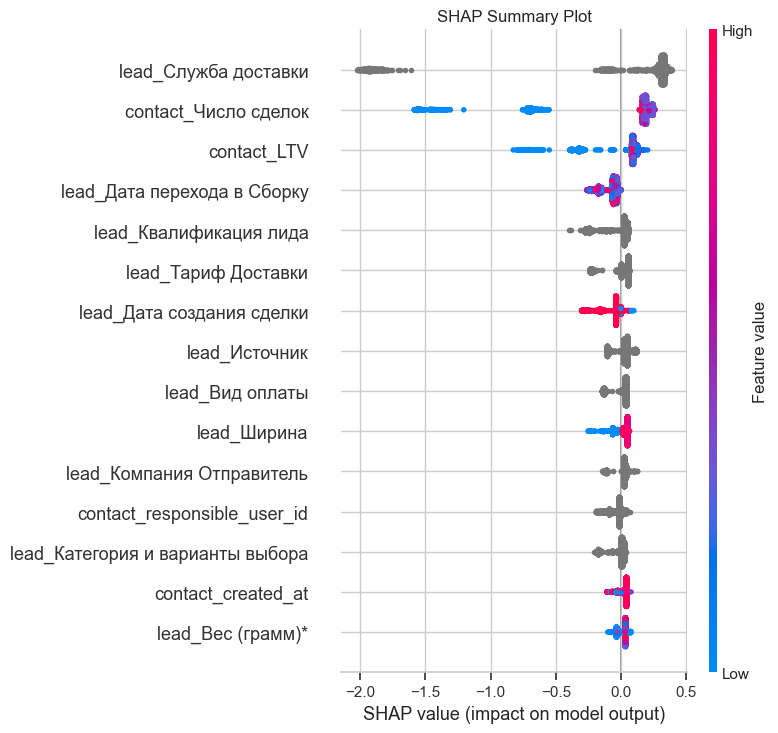

In [10]:
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot', fontsize=12)
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.show()

## 7. Финансовая симуляция

Оценка экономического эффекта. Расчет агрегированной маржи при различных порогах отсечения вероятности (thresholds) с учетом стоимости логистики при отказах. Сравнение с baseline-стратегией (отправка всех заказов).

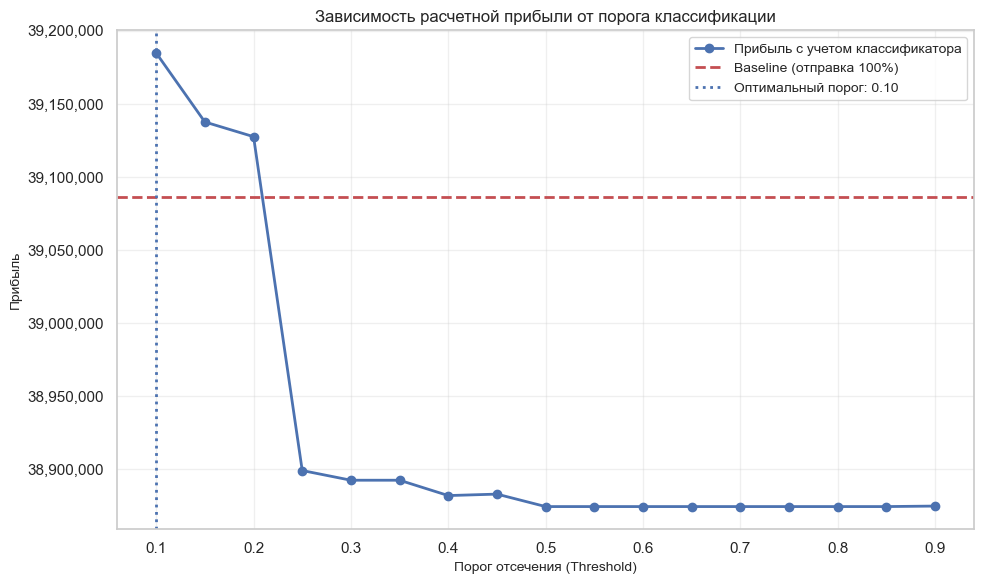

Результаты финансового моделирования:
Прибыль (Baseline):        39,086,155 руб.
Прибыль (CatBoost):        39,184,803 руб.
Дельта (Бизнес-эффект):    +98,648 руб.


In [11]:
LOGISTICS_COST = 1000
thresholds = np.arange(0.1, 0.95, 0.05)

lead_prices = test_df['lead_price'].values
actual_outcomes = y_test.values

baseline_profit = np.sum(lead_prices[actual_outcomes == 1]) - (np.sum(actual_outcomes == 0) * LOGISTICS_COST)
profits = []

for thresh in thresholds:
    preds = (y_pred_proba >= thresh).astype(int)
    
    tp_mask = (preds == 1) & (actual_outcomes == 1)
    profit_tp = np.sum(lead_prices[tp_mask])
    
    fp_mask = (preds == 1) & (actual_outcomes == 0)
    loss_fp = np.sum(fp_mask) * LOGISTICS_COST
    
    profits.append(profit_tp - loss_fp)

best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
max_profit = profits[best_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, marker='o', lw=2, label='Прибыль с учетом классификатора')
plt.axhline(y=baseline_profit, color='r', linestyle='--', lw=2, label='Baseline (отправка 100%)')
plt.axvline(x=best_threshold, color='b', linestyle=':', lw=2, label=f'Оптимальный порог: {best_threshold:.2f}')

plt.title('Зависимость расчетной прибыли от порога классификации', fontsize=12)
plt.xlabel('Порог отсечения (Threshold)', fontsize=10)
plt.ylabel('Прибыль', fontsize=10)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Результаты финансового моделирования:")
print(f"Прибыль (Baseline):        {int(baseline_profit):,} руб.")
print(f"Прибыль (CatBoost):        {int(max_profit):,} руб.")
print(f"Дельта (Бизнес-эффект):    +{int(max_profit - baseline_profit):,} руб.")

## 8. Сравнение с другой моделью (LightGBM) (Это нужно будет убрать для чистовика как обсудим с командой)

In [12]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import numpy as np

print("Инициализация данных для LightGBM...")

# LightGBM требует строгой типизации категориальных признаков как pandas 'category'
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

# Инициализация модели
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    random_state=42,
    learning_rate=0.05,
    max_depth=6, # Ограничение глубины для предотвращения переобучения
    n_jobs=-1
)

# Обучение с ранней остановкой
print("Запуск обучения LightGBM...")
lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Расчет метрик
y_pred_lgb = lgb_model.predict(X_test_lgb)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("\nМетрики качества LightGBM:")
print(f"ROC-AUC:   {auc_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall:    {recall_lgb:.4f}")
print(f"F1-score:  {f1_lgb:.4f}")

# Финансовый симулятор для LightGBM
profits_lgb = []
for thresh in thresholds:
    preds = (y_pred_proba_lgb >= thresh).astype(int)
    
    tp_mask = (preds == 1) & (actual_outcomes == 1)
    profit_tp = np.sum(lead_prices[tp_mask])
    
    fp_mask = (preds == 1) & (actual_outcomes == 0)
    loss_fp = np.sum(fp_mask) * LOGISTICS_COST
    
    profits_lgb.append(profit_tp - loss_fp)

best_idx_lgb = np.argmax(profits_lgb)
max_profit_lgb = profits_lgb[best_idx_lgb]

print("\nРезультаты финансового моделирования (LightGBM):")
print(f"Прибыль (Baseline):        {int(baseline_profit):,} руб.")
print(f"Прибыль (LightGBM):        {int(max_profit_lgb):,} руб.")
print(f"Дельта (Бизнес-эффект):    +{int(max_profit_lgb - baseline_profit):,} руб.")

Инициализация данных для LightGBM...
Запуск обучения LightGBM...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11978, number of negative: 2082
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5383
[LightGBM] [Info] Number of data points in the train set: 14060, number of used features: 59
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.851920 -> initscore=1.749743
[LightGBM] [Info] Start training from score 1.749743
[LightGBM] [Warning] No further splits with positive 